# 02 · Análisis Exploratorio (EDA)

Exploración de los 13 279 córners de Liga MX a través de distribuciones, mix táctico, zonas de entrega y posicionamiento StatsBomb 360.

Este notebook carga directamente desde `data/processed/` — no requiere re-correr el preprocessing. Cada subsección es independiente y puede ejecutarse por separado siempre que la celda de setup haya corrido.

## Contenido

| Subsección | Análisis |
|---|---|
| 1.0 | Inventario de columnas por dataset |
| 1.1 | Distribución por torneo y etapa |
| 1.2 | Ranking de equipos por efectividad |
| 1.3 | Mix táctico global y por equipo |
| 1.4 | Zona de destino del envío (pitch map) |
| 1.5 | Distribución temporal |
| 1.6 | Lado del córner y pie de envío |
| 1.7 | Visualizaciones de resumen |
| 1.8 | Zonas de remate por origen |
| 1.9 | Córner aleatorio con freeze frame 360 |

In [39]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import os

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch, FontManager
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='husl')

_here = Path().resolve()
_root = _here.parent if _here.name == 'notebooks' else _here
RAW_DIR       = _root / 'data' / 'raw'
PROCESSED_DIR = _root / 'data' / 'processed'
Path(_root / 'figures').mkdir(exist_ok=True)
print('OK')

OK


---

## 1 · EDA - Exploración de córners

### 1.0 · Inventario de datasets y features

Carga de los datasets procesados y revisión de columnas disponibles — tipos de dato, cobertura y ejemplo — antes de cualquier análisis.

In [40]:
# Cargar datasets desde processed/ (evita re-filtrar 4.4M eventos cada sesión)
corner_features = pd.read_parquet(PROCESSED_DIR / 'corner_features.parquet')
from_corner_enr = pd.read_parquet(PROCESSED_DIR / 'from_corner_enriched.parquet')
shots_fc        = pd.read_parquet(PROCESSED_DIR / 'shots_from_corner.parquet')
shots_sp        = pd.read_parquet(PROCESSED_DIR / 'shots_second_phase.parquet')

# Paleta y constantes — reutilizadas en todas las celdas de sección 4
TYPES       = ['Inswinging', 'Outswinging', 'Short', 'Straight']
COLORS_TYPE = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']
BG          = '#0d1b2a'   # fondo oscuro unificado para pitch maps

print(f'corner_features:      {corner_features.shape[0]:>6,} filas × {corner_features.shape[1]:>3} cols')
print(f'from_corner_enriched: {from_corner_enr.shape[0]:>6,} filas × {from_corner_enr.shape[1]:>3} cols')
print(f'shots_from_corner:    {shots_fc.shape[0]:>6,} filas × {shots_fc.shape[1]:>3} cols')
print(f'shots_second_phase:   {shots_sp.shape[0]:>6,} filas × {shots_sp.shape[1]:>3} cols')

corner_features:      13,279 filas ×  60 cols
from_corner_enriched: 124,740 filas × 153 cols
shots_from_corner:     5,607 filas × 143 cols
shots_second_phase:      110 filas × 150 cols


In [41]:
# ── Inventario de columnas por dataset — dtype + cobertura + ejemplo ─────────
def feature_inventory(df, name):
    rows = []
    for col in df.columns:
        try:
            ex = str(df[col].dropna().iloc[0])[:50] if df[col].notna().any() else 'NaN'
        except Exception:
            ex = 'N/A'
        rows.append({
            'column': col,
            'dtype':  str(df[col].dtype),
            'null_%': round(df[col].isna().mean() * 100, 1),
            'example': ex,
        })
    info = pd.DataFrame(rows).set_index('column')
    print(f'\n{"─"*65}')
    print(f'  {name}  ({df.shape[0]:,} filas × {df.shape[1]} cols)')
    print(f'{"─"*65}')
    print(info.to_string())

feature_inventory(corner_features, 'corner_features  ← dataset maestro')
feature_inventory(shots_fc,        'shots_from_corner')
feature_inventory(shots_sp,        'shots_second_phase')


─────────────────────────────────────────────────────────────────
  corner_features  ← dataset maestro  (13,279 filas × 60 cols)
─────────────────────────────────────────────────────────────────
                                       dtype  null_%                               example
column                                                                                    
id                                       str     0.0  3c9ff11d-d1f1-5643-a0bc-a8c3332b8bc5
match_id                               int64     0.0                               3972090
possession                             int64     0.0                                    55
team                                     str     0.0                             Monterrey
team_id                                int64     0.0                                  1222
player                                   str     0.0                Sergio Canales Madrazo
player_id                            float64     0.0                        

### 1.1 · Distribución por torneo y etapa

In [42]:
# ── 4.1 · Distribución por torneo y etapa ──────────────────────────────────
season_dist = (
    corner_features
    .groupby(['season', 'competition_stage'], observed=True)
    .agg(
        n_corners     = ('id', 'count'),
        shot_rate     = ('generated_shot', 'mean'),
        counter_rate  = ('led_to_counter', 'mean'),
        retained_rate = ('sequence_outcome', lambda x: (x == 'retained').mean()),
        xg_mean       = ('seq_max_xg', lambda x: x.fillna(0).mean()),
        obv_mean      = ('obv_total_net', 'mean'),
    )
    .reset_index()
    .sort_values(['season', 'competition_stage'])
)
for col in ['shot_rate', 'counter_rate', 'retained_rate']:
    season_dist[col] = (season_dist[col] * 100).round(1)
season_dist[['xg_mean', 'obv_mean']] = season_dist[['xg_mean', 'obv_mean']].round(4)
print(season_dist.to_string(index=False))

   season          competition_stage  n_corners  shot_rate  counter_rate  retained_rate  xg_mean  obv_mean
2021/2022                   Apertura       1373       36.9           0.8           24.3   0.0305    0.0066
2021/2022          Apertura - Finals          5       40.0           0.0            0.0   0.0186    0.0207
2021/2022  Apertura - Quarter-finals         61       27.9           0.0           31.1   0.0293    0.0066
2021/2022 Apertura - Reclasificación         36       33.3           5.6           19.4   0.0114   -0.0065
2021/2022     Apertura - Semi-finals         48       35.4           0.0           22.9   0.0409   -0.0035
2021/2022                   Clausura       1446       38.2           0.8           22.9   0.0323    0.0090
2021/2022           Clausura - Final         15       13.3           0.0           20.0   0.0068   -0.0103
2021/2022 Clausura - Reclasificacion         42       45.2           0.0           19.0   0.0443    0.0113
2021/2022             Quarter-finals 

### 1.2 · Ranking de equipos

In [43]:
# ── 4.2 · Ranking de equipos ──────────────────────────────────────────────
team_stats = (
    corner_features
    .groupby('team', observed=True)
    .agg(
        n_corners     = ('id', 'count'),
        shot_rate     = ('generated_shot', 'mean'),
        counter_rate  = ('led_to_counter', 'mean'),
        retained_rate = ('sequence_outcome', lambda x: (x == 'retained').mean()),
        obv_mean      = ('obv_total_net', 'mean'),
        xg_mean       = ('seq_max_xg', lambda x: x.fillna(0).mean()),
        xg_total      = ('seq_max_xg', lambda x: x.fillna(0).sum()),
    )
    .reset_index()
    .sort_values('xg_mean', ascending=False)
)
for col in ['shot_rate', 'counter_rate', 'retained_rate']:
    team_stats[col] = (team_stats[col] * 100).round(1)
team_stats[['obv_mean', 'xg_mean']] = team_stats[['obv_mean', 'xg_mean']].round(4)
team_stats['xg_total'] = team_stats['xg_total'].round(2)

print('Top 10 por xG medio/córner:')
print(team_stats.head(10).to_string(index=False))
print()
print('Bottom 5 (menor efectividad):')
print(team_stats.tail(5).to_string(index=False))

Top 10 por xG medio/córner:
             team  n_corners  shot_rate  counter_rate  retained_rate  obv_mean  xg_mean  xg_total
      Tigres UANL        908       38.8           0.7           25.6    0.0077   0.0392     35.56
         Mazatlán        583       41.3           0.3           19.2    0.0121   0.0379     22.11
    Santos Laguna        779       38.3           1.7           24.3    0.0150   0.0374     29.17
             León        758       38.5           0.5           21.0    0.0099   0.0374     28.33
           Puebla        641       42.9           0.9           21.8    0.0069   0.0362     23.19
           Toluca        731       37.9           0.5           22.7    0.0092   0.0346     25.31
Atlético San Luis        654       39.1           0.9           23.5    0.0116   0.0346     22.63
          América        912       37.2           1.0           21.4    0.0096   0.0344     31.36
        Cruz Azul        824       38.3           0.6           26.9    0.0069   0.0335   

### 1.3 · Mix táctico

In [44]:
# ── 4.3 · Mix táctico global ──────────────────────────────────────────────
type_mix = (
    corner_features
    .groupby('corner_type', observed=True)
    .agg(
        n             = ('id', 'count'),
        shot_rate     = ('generated_shot', 'mean'),
        counter_rate  = ('led_to_counter', 'mean'),
        retained_rate = ('sequence_outcome', lambda x: (x == 'retained').mean()),
        obv_mean      = ('obv_total_net', 'mean'),
        xg_mean       = ('seq_max_xg', lambda x: x.fillna(0).mean()),
    )
    .assign(pct=lambda df: (df['n'] / df['n'].sum() * 100).round(1))
    .reset_index()
)
TYPES = ['Inswinging', 'Outswinging', 'Short', 'Straight']
type_mix = type_mix.set_index('corner_type').reindex(TYPES).reset_index()
for col in ['shot_rate', 'counter_rate', 'retained_rate']:
    type_mix[col] = (type_mix[col] * 100).round(1)
type_mix[['obv_mean', 'xg_mean']] = type_mix[['obv_mean', 'xg_mean']].round(4)
print('Mix global por tipo de envío:')
print(type_mix.to_string(index=False))

# Nota clusters: StatsBomb asigna 60 clusters semánticos al 25% de pases del dataset,
# pero EXCLUYE deliberadamente los córners (0% cobertura en corners — ya tienen pass_technique).
# Los clusters SÍ están en pases DENTRO de la secuencia (from_corner_enriched).
seq_clusters = (
    from_corner_enr[from_corner_enr['type'] == 'Pass']['pass_pass_cluster_label'].dropna()
)
print(f'\nClusters en pases dentro de secuencias de córner (n={len(seq_clusters):,}):')
if len(seq_clusters) > 0:
    print(seq_clusters.value_counts().head(10).to_string())
else:
    print('Sin datos de cluster en pases de secuencia.')

Mix global por tipo de envío:
corner_type    n  shot_rate  counter_rate  retained_rate  obv_mean  xg_mean  pct
 Inswinging 4594       34.1           0.7           24.2    0.0151   0.0346 34.6
Outswinging 5590       42.4           0.9           20.7    0.0121   0.0343 42.1
      Short 2644       34.0           0.8           26.0   -0.0091   0.0277 19.9
   Straight  451       41.9           0.7           20.8    0.0115   0.0294  3.4

Clusters en pases dentro de secuencias de córner (n=21,339):
pass_pass_cluster_label
Attacking third - Right - To left - Short - Ground Pass      1680
Attacking third - Right - To left - Short - High Pass        1483
Attacking third - Left - Backwards - Short - Ground Pass     1437
Attacking third - Left - To right - Short - High Pass        1356
Attacking third - Left - To right - Short - Ground Pass      1314
Attacking third - Right - Backwards - Short - Ground Pass    1144
Attacking third - Right - Forwards - Short - Ground Pass     1113
Midfield third - 

### 1.4 · Zona de destino del envío

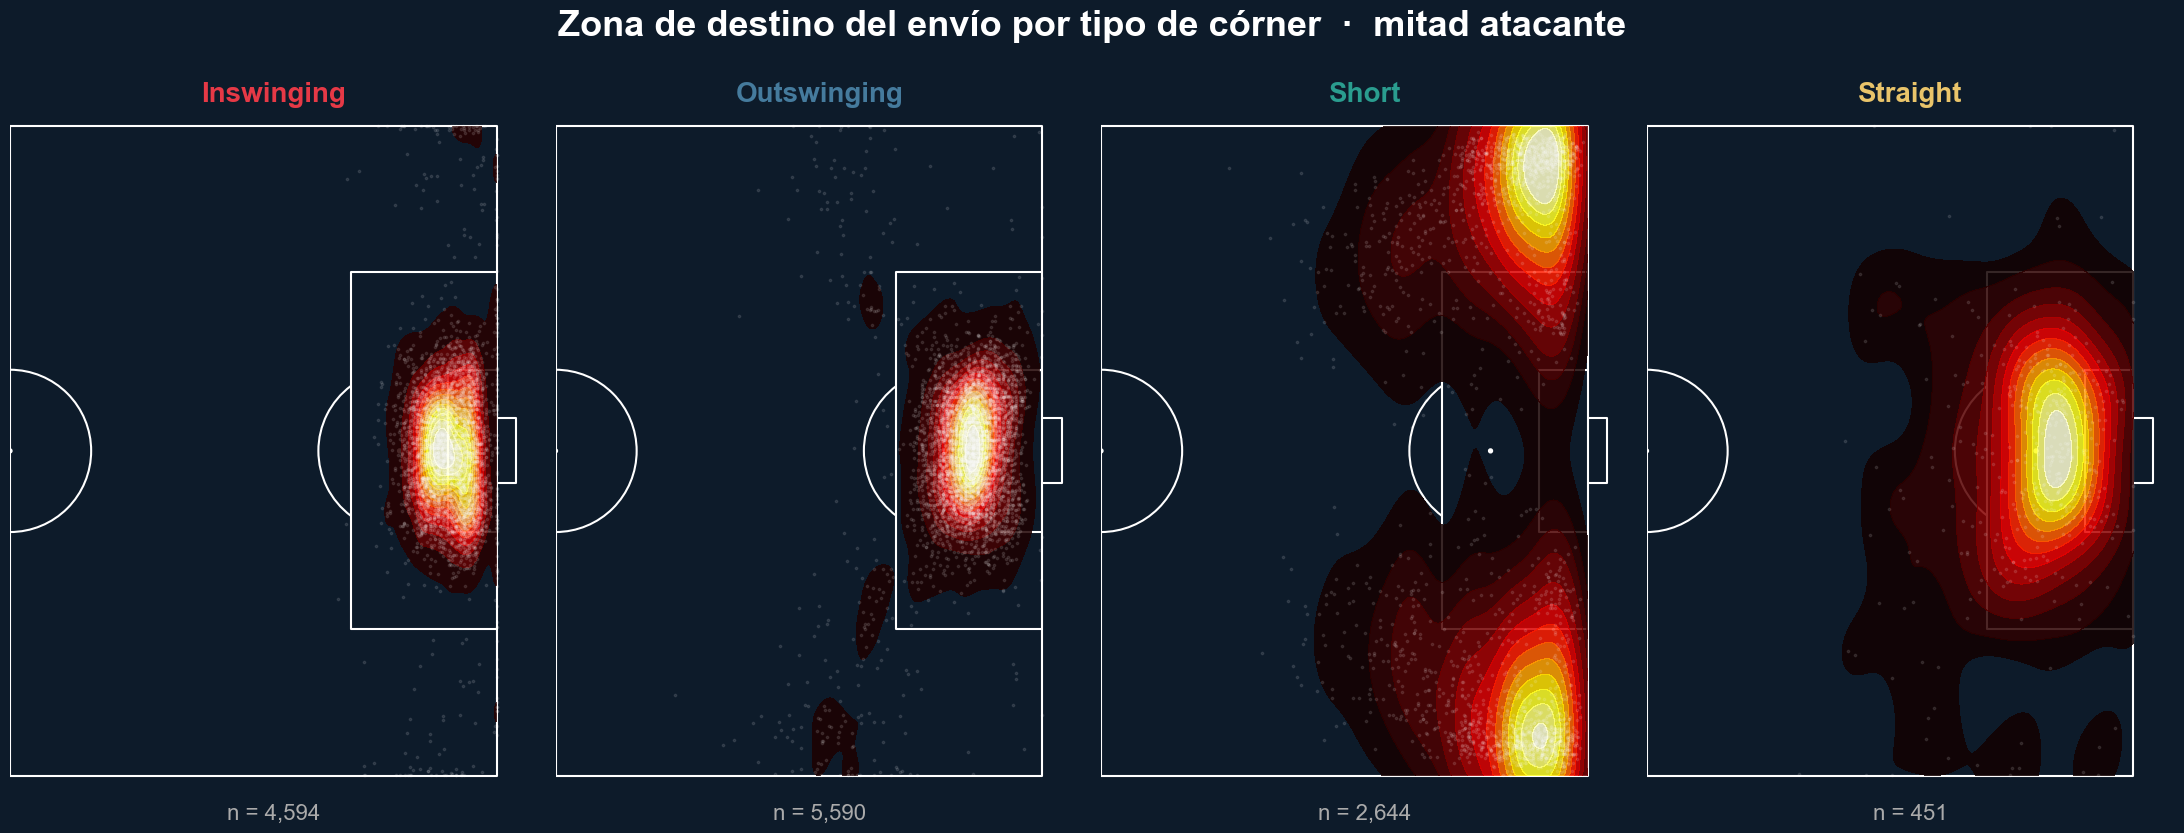

In [59]:
# ── 4.4 · Zona de destino del envío — vista de mitad atacante ───────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 8))

for ax, ctype, color in zip(axes, TYPES, COLORS_TYPE):
    pitch = Pitch(pitch_type='statsbomb', pitch_color=BG, line_color='#ffffff66',
                  linewidth=1.5, goal_type='box')
    pitch.draw(ax=ax)
    sub = corner_features[corner_features['corner_type'] == ctype].dropna(subset=['end_x', 'end_y'])
    if len(sub) > 10:
        pitch.kdeplot(sub['end_x'], sub['end_y'], ax=ax,
                      cmap='hot', fill=True, alpha=0.85, levels=14, thresh=0.04)
        pitch.scatter(sub['end_x'], sub['end_y'], ax=ax,
                      s=3, alpha=0.1, color='white', zorder=3)
    ax.set_xlim(60, 125)
    ax.set_ylim(-2, 82)
    ax.set_title(ctype, color=color, fontsize=20, fontweight='bold', pad=6)
    ax.text(0.5, -0.04, f'n = {len(sub):,}', transform=ax.transAxes,
            ha='center', color='#aaaaaa', fontsize=16)
    ax.set_facecolor(BG)

fig.patch.set_facecolor(BG)
fig.suptitle('Zona de destino del envío por tipo de córner  ·  mitad atacante',
             color='white', fontsize=26, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/corner_delivery_zones.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

### 1.5 · Distribución temporal

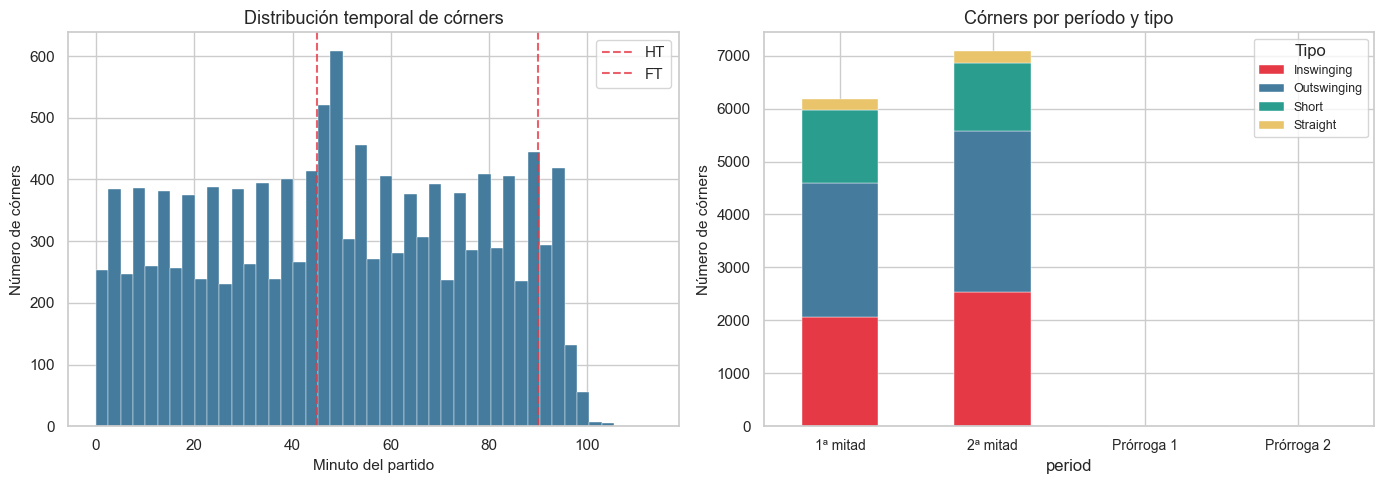

In [46]:
# ── 4.5 · Distribución temporal ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(corner_features['minute'], bins=45, color='#457b9d', edgecolor='white', linewidth=0.3)
for m, label in [(45, 'HT'), (90, 'FT')]:
    ax1.axvline(m, color='#e63946', linestyle='--', alpha=0.8, label=label)
ax1.set_xlabel('Minuto del partido', fontsize=11)
ax1.set_ylabel('Número de córners', fontsize=11)
ax1.set_title('Distribución temporal de córners', fontsize=13)
ax1.legend()

period_type = (
    corner_features
    .groupby(['period', 'corner_type'], observed=True)['id'].count()
    .unstack(fill_value=0)
    .reindex(columns=TYPES, fill_value=0)
)
period_type.index = period_type.index.map(
    {1: '1ª mitad', 2: '2ª mitad', 3: 'Prórroga 1', 4: 'Prórroga 2'}
)
period_type.plot(kind='bar', stacked=True, ax=ax2, color=COLORS_TYPE, edgecolor='white', linewidth=0.3)
ax2.set_title('Córners por período y tipo', fontsize=13)
ax2.set_ylabel('Número de córners', fontsize=11)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0, fontsize=10)
ax2.legend(title='Tipo', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/corner_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.6 · Lado del córner y pie de envío

In [47]:
# ── 4.6 · Lado del córner × pie de envío ─────────────────────────────────────
# Pie dominante en córner = pie CONTRARIO al banderín:
#   • córner izquierdo (y<40) + pie DERECHO → bola curva hacia dentro → Inswinging
#   • córner derecho  (y>40) + pie IZQUIERDO → bola curva hacia dentro → Inswinging
#   • mismo lado (cruzado) → bola sale alejándose → Outswinging / Straight

side_body = (
    corner_features
    .groupby(['corner_side', 'pass_body_part'], observed=True)['id'].count()
    .unstack(fill_value=0)
)
print('Lado × pie de envío (nº de córners):')
print(side_body)

dominant = (
    ((corner_features['corner_side'] == 'left')  & (corner_features['pass_body_part'] == 'Right Foot')) |
    ((corner_features['corner_side'] == 'right') & (corner_features['pass_body_part'] == 'Left Foot'))
)
print(f'\nPie dominante (contrario al banderín): {dominant.mean():.1%}  ({dominant.sum():,})')
print(f'Pie cruzado   (mismo lado que banderín): {(~dominant).mean():.1%}  ({(~dominant).sum():,})')

print('\n% pie dominante por tipo (inswing=100%, outswing=0% es lo esperado físicamente):')
dom_by_type = (
    corner_features
    .assign(dominant_foot=dominant)
    .groupby('corner_type', observed=True)['dominant_foot']
    .mean().mul(100).round(1)
    .reindex(TYPES)
)
print(dom_by_type.to_string())
print('\n→ Inswinging: siempre pie dominante · Outswinging: siempre pie cruzado')
print('  Short y Straight mezclan ambos (no hay swinging commitment).')

Lado × pie de envío (nº de córners):
pass_body_part  Left Foot  Right Foot
corner_side                          
left                 2563        3868
right                2717        4131

Pie dominante (contrario al banderín): 49.6%  (6,585)
Pie cruzado   (mismo lado que banderín): 50.4%  (6,694)

% pie dominante por tipo (inswing=100%, outswing=0% es lo esperado físicamente):
corner_type
Inswinging     100.0
Outswinging      0.0
Short           66.1
Straight        53.9

→ Inswinging: siempre pie dominante · Outswinging: siempre pie cruzado
  Short y Straight mezclan ambos (no hay swinging commitment).


### 1.7 · Visualizaciones de resumen

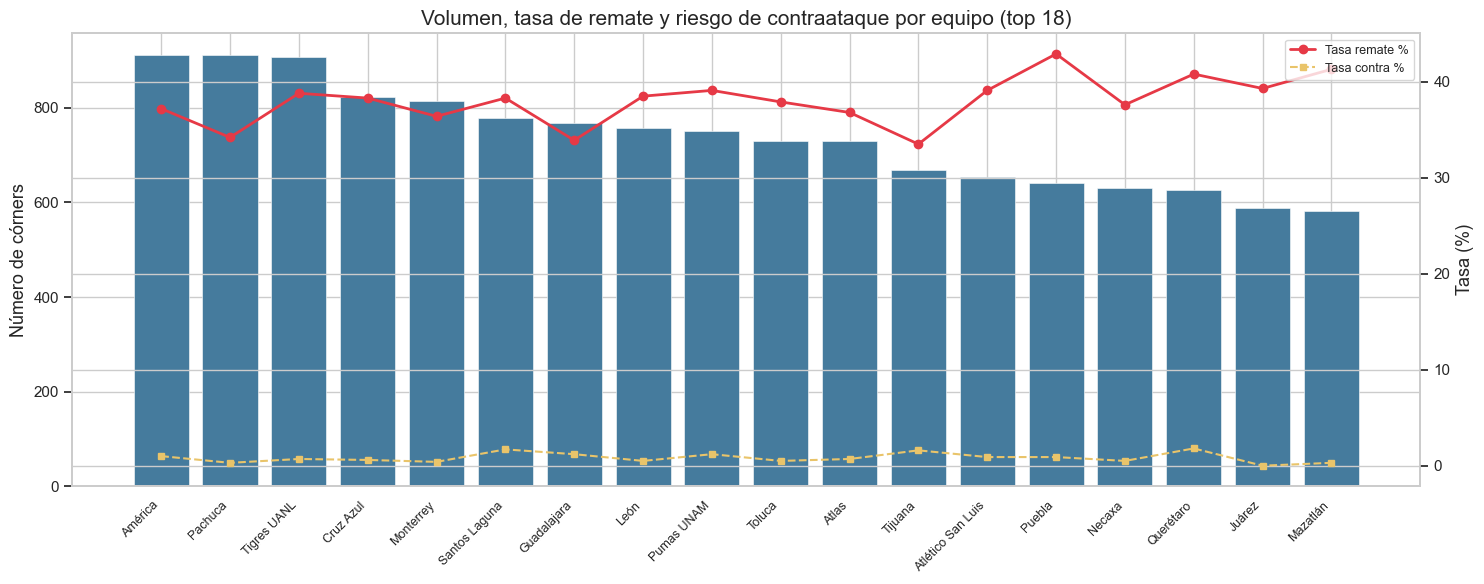

In [61]:
# ── Volumen, tasa de remate y riesgo por equipo (top 18) ─────────────────────
top18 = team_stats.nlargest(18, 'n_corners').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(top18['team'], top18['n_corners'], color='#457b9d', edgecolor='white', linewidth=0.4)
ax2 = ax.twinx()
ax2.plot(range(len(top18)), top18['shot_rate'],    'o-', color='#e63946', lw=2, ms=6, label='Tasa remate %')
ax2.plot(range(len(top18)), top18['counter_rate'], 's--', color='#e9c46a', lw=1.5, ms=5, label='Tasa contra %')
ax.set_ylabel('Número de córners', fontsize=13)
ax2.set_ylabel('Tasa (%)', fontsize=13)
ax.set_xticklabels(top18['team'], rotation=45, ha='right', fontsize=9)
ax2.legend(fontsize=9, loc='upper right')
ax.set_title('Volumen, tasa de remate y riesgo de contraataque por equipo (top 18)', fontsize=15)
plt.tight_layout()
plt.savefig('../figures/team_corner_volume.png', dpi=150, bbox_inches='tight')
plt.show()

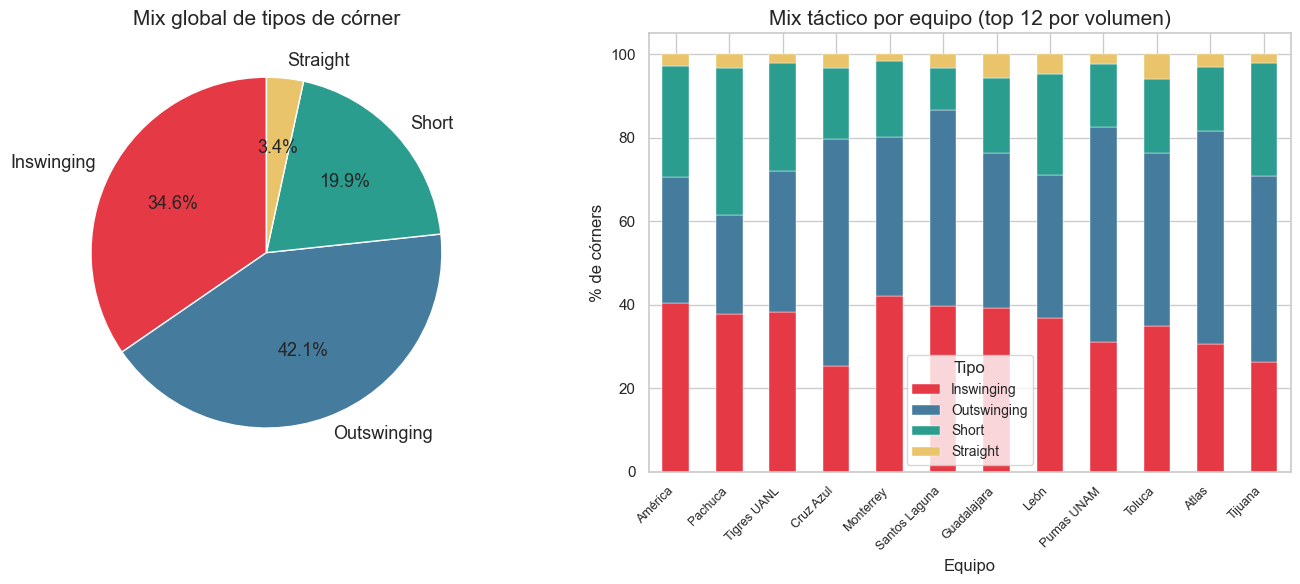

In [63]:
# ── Mix global (pie) y por equipo (barras apiladas) ──────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.pie(type_mix['n'], labels=type_mix['corner_type'], autopct='%1.1f%%',
        colors=COLORS_TYPE, startangle=90, textprops={'fontsize': 13})
ax1.set_title('Mix global de tipos de córner', fontsize=15)

top12 = (
    corner_features
    .groupby(['team', 'corner_type'], observed=True)['id'].count()
    .unstack(fill_value=0)
)
top12 = top12.loc[top12.sum(axis=1).nlargest(12).index]
top12_pct = (
    top12.div(top12.sum(axis=1), axis=0)
    .mul(100)
    .reindex(columns=TYPES, fill_value=0)
)
top12_pct.plot(kind='bar', stacked=True, ax=ax2, color=COLORS_TYPE, edgecolor='white', linewidth=0.3)
ax2.set_title('Mix táctico por equipo (top 12 por volumen)', fontsize=15)
ax2.set_ylabel('% de córners', fontsize=12)
ax2.set_xlabel('Equipo', fontsize=12)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax2.legend(title='Tipo', fontsize=10)
plt.tight_layout()
plt.savefig('../figures/corner_type_mix.png', dpi=150, bbox_inches='tight')
plt.show()

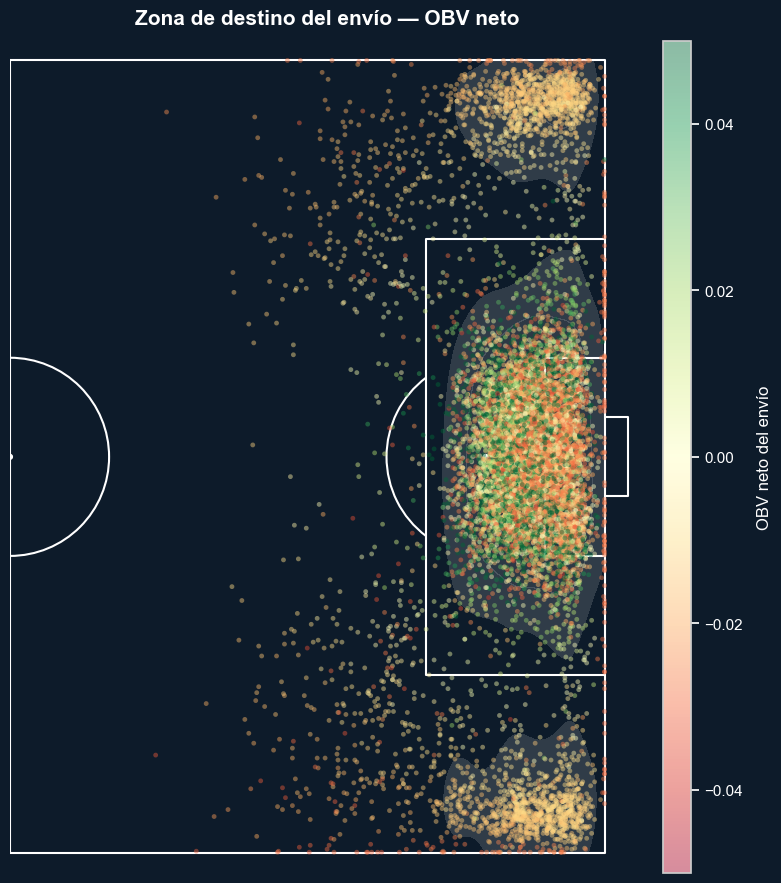

In [66]:
# ── Destino del envío coloreado por OBV ──────────────────────────────────────
BG = '#0d1b2a'
fig, ax = plt.subplots(figsize=(14, 9))
pitch = Pitch(pitch_type='statsbomb', pitch_color=BG, line_color='#ffffff55',
              linewidth=1.5, goal_type='box')
pitch.draw(ax=ax)

sub = corner_features.dropna(subset=['end_x', 'end_y', 'obv_total_net'])

# Densidad de fondo (todos los córners)
pitch.kdeplot(sub['end_x'], sub['end_y'], ax=ax,
              cmap='Greys', alpha=0.15, fill=True, levels=6, thresh=0.1)

# Scatter coloreado por OBV
sc = pitch.scatter(sub['end_x'], sub['end_y'], ax=ax,
                   c=sub['obv_total_net'], cmap='RdYlGn',
                   s=12, alpha=0.45, zorder=3,
                   vmin=-0.05, vmax=0.05, linewidths=0)

cbar = fig.colorbar(sc, ax=ax, orientation='vertical',
                    pad=0.015, fraction=0.025, aspect=30)
cbar.set_label('OBV neto del envío', color='white', fontsize=12, labelpad=10)
cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')

ax.set_xlim(60, 124)
ax.set_ylim(-2, 82)
ax.set_title('Zona de destino del envío — OBV neto',
             color='white', fontsize=15, pad=12, fontweight='bold')
ax.set_facecolor(BG)
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.savefig('../figures/delivery_obv_scatter.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

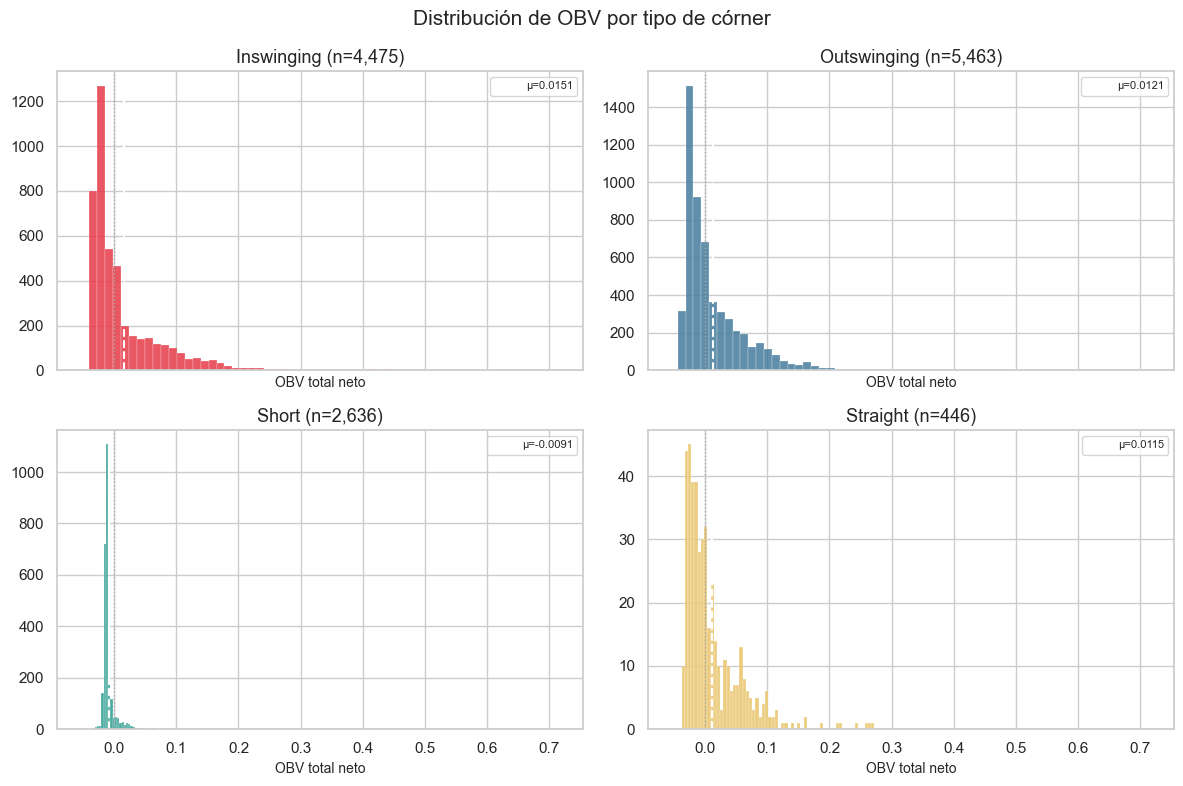

In [67]:
# ── Distribución de OBV por tipo de córner ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, ctype, color in zip(axes.flat, TYPES, COLORS_TYPE):
    data = corner_features[corner_features['corner_type'] == ctype]['obv_total_net'].dropna()
    ax.hist(data, bins=60, color=color, alpha=0.85, edgecolor='white', linewidth=0.2)
    ax.axvline(data.mean(), color='white', linestyle='--', linewidth=1.5, label=f'μ={data.mean():.4f}')
    ax.axvline(0, color='#aaaaaa', linestyle=':', linewidth=1)
    ax.set_title(f'{ctype} (n={len(data):,})', fontsize=13)
    ax.set_xlabel('OBV total neto', fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle('Distribución de OBV por tipo de córner', fontsize=15)
plt.tight_layout()
plt.savefig('../figures/obv_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.8 · Zonas de remate por origen

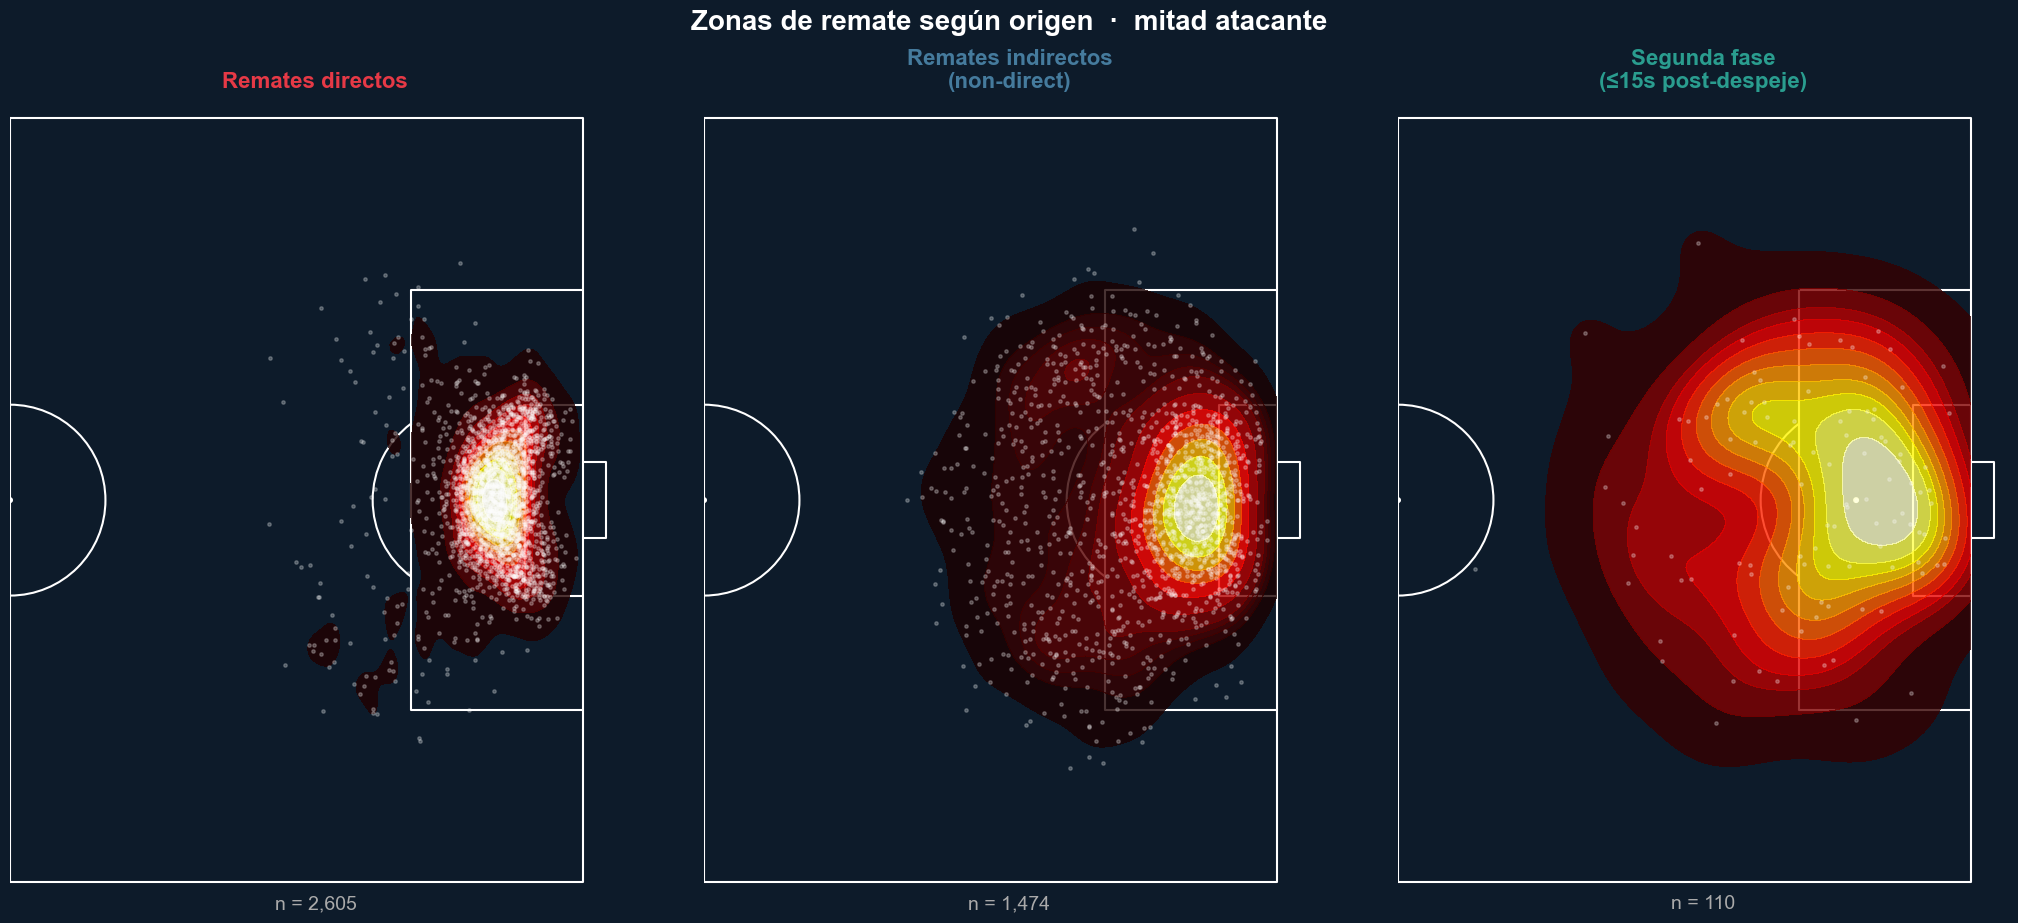

In [ ]:
# ── 4.8 · Zonas de remate por origen ─────────────────────────────────────────
def get_xy(df, col='location'):
    """Extrae x, y de columnas que pueden ser list, tuple o numpy array."""
    locs = df[col].dropna()
    xs = locs.apply(lambda l: float(l[0]) if hasattr(l, '__len__') and len(l) >= 2 else None).dropna()
    ys = locs.apply(lambda l: float(l[1]) if hasattr(l, '__len__') and len(l) >= 2 else None).dropna()
    return xs.values, ys.values

datasets = [
    ('Remates directos',                   shots_fc[shots_fc['shot_origin'] == 'direct'],     '#e63946'),
    ('Remates indirectos\n(non-direct)',   shots_fc[shots_fc['shot_origin'] == 'non_direct'], '#457b9d'),
    ('Segunda fase\n(≤15s post-despeje)',  shots_sp,                                           '#2a9d8f'),
]

fig, axes = plt.subplots(1, 3, figsize=(21, 9))
for ax, (title, df, color) in zip(axes, datasets):
    pitch = Pitch(pitch_type='statsbomb', pitch_color=BG, line_color='#ffffff66',
                  linewidth=1.5, goal_type='box')
    pitch.draw(ax=ax)
    xs, ys = get_xy(df)
    if len(xs) > 5:
        pitch.kdeplot(xs, ys, ax=ax, cmap='hot', fill=True, alpha=0.8, levels=12, thresh=0.04)
        pitch.scatter(xs, ys, ax=ax, s=6, alpha=0.25, color='white', zorder=4)
    ax.set_xlim(60, 124)
    ax.set_ylim(-2, 82)
    ax.set_title(title, color=color, fontsize=16, fontweight='bold', pad=8)
    ax.text(0.5, -0.01, f'n = {len(df):,}', transform=ax.transAxes,
            ha='center', color='#aaaaaa', fontsize=14)
    ax.set_facecolor(BG)

fig.patch.set_facecolor(BG)
fig.suptitle('Zonas de remate según origen  ·  mitad atacante',
             color='white', fontsize=20, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/shot_locations.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

### 1.9 · Córner aleatorio — jugadores en cancha

Usa el freeze frame 360 si está disponible (jugadores en posición real al momento del remate). Fallback: traza de eventos de la secuencia. Cada ejecución muestra un córner distinto.

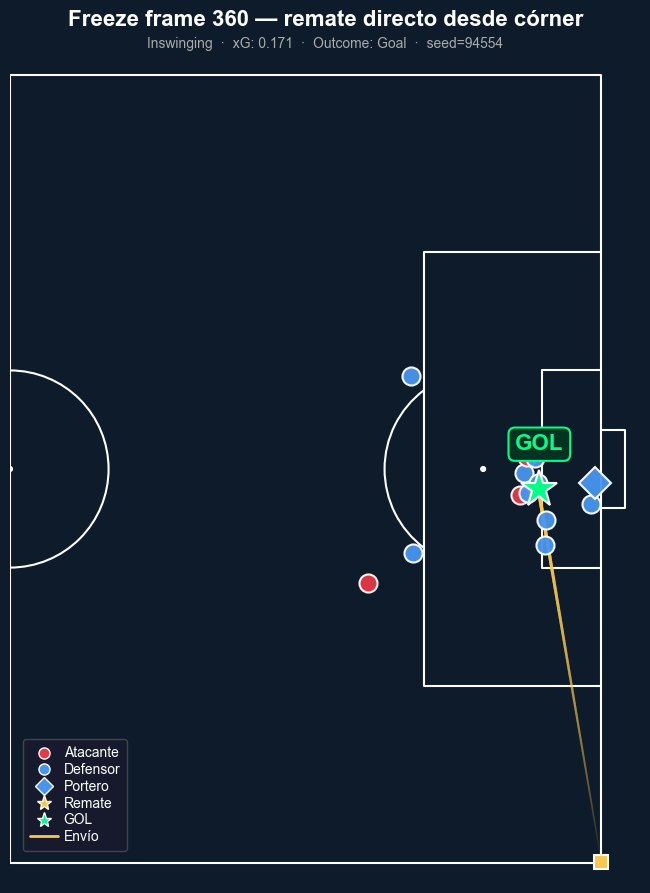

In [133]:
# ── 1.9 · Córner aleatorio — jugadores en cancha ────────────────────────────
import random
rng_seed = random.randint(0, 99999)

ff_col = next((c for c in shots_fc.columns if 'freeze_frame' in c.lower()), None)
direct_ff = (
    shots_fc[(shots_fc['shot_origin'] == 'direct') & shots_fc[ff_col].notna()]
    if ff_col else pd.DataFrame()
)

fig, ax = plt.subplots(figsize=(14, 9))
pitch = Pitch(pitch_type='statsbomb', pitch_color=BG, line_color='#ffffff66',
              linewidth=1.5, goal_type='box')
pitch.draw(ax=ax)

if len(direct_ff) > 0:
    row     = direct_ff.sample(1, random_state=rng_seed).iloc[0]
    ff      = list(row[ff_col]) if hasattr(row[ff_col], '__len__') else []
    is_goal = str(row.get('shot_outcome', '')).lower() == 'goal'

    corner_row = corner_features[corner_features['id'] == row['shot_key_pass_id']]
    if len(corner_row) > 0:
        cr = corner_row.iloc[0]
        if pd.notna(cr['corner_x']) and pd.notna(cr['end_x']):
            pitch.lines(float(cr['corner_x']), float(cr['corner_y']),
                        float(cr['end_x']),    float(cr['end_y']),
                        ax=ax, color='#f9c74f', lw=2.5, zorder=4,
                        comet=True, transparent=True)
            ax.plot(float(cr['corner_x']), float(cr['corner_y']),
                    's', color='#f9c74f', ms=10, mec='white', mew=1.5, zorder=5)

    for player in ff:
        loc    = player.get('location')
        if not hasattr(loc, '__len__') or len(loc) < 2: continue
        is_att = player.get('teammate', False)
        pos_id = player.get('position', {}).get('id') if isinstance(player.get('position'), dict) else None
        is_gk  = (pos_id == 1)
        color  = '#e63946' if is_att else '#4895ef'
        marker = 'D' if is_gk else 'o'
        ax.plot(float(loc[0]), float(loc[1]), marker=marker, color=color,
                ms=16 if is_gk else 13, alpha=0.95, mec='white', mew=1.5, zorder=6)

    sloc = row['location']
    if hasattr(sloc, '__len__') and len(sloc) >= 2:
        star_color = '#00ff88' if is_goal else '#f9c74f'
        ax.plot(float(sloc[0]), float(sloc[1]), '*', color=star_color,
                ms=28, zorder=8, mec='white', mew=1.5)
        if is_goal:
            ax.text(float(sloc[0]), float(sloc[1]) + 3.5, 'GOL',
                    color='#00ff88', fontsize=16, fontweight='bold',
                    ha='center', va='bottom', zorder=9,
                    bbox=dict(boxstyle='round,pad=0.3', fc='#003322', ec='#00ff88', lw=1.5))

    xg  = row.get('shot_statsbomb_xg', float('nan'))
    out = row.get('shot_outcome', 'N/A')
    ct  = corner_row.iloc[0]['corner_type'] if len(corner_row) > 0 else '?'
    main_title = 'Freeze frame 360 — remate directo desde córner'
    subtitle   = f'{ct}  ·  xG: {xg:.3f}  ·  Outcome: {out}  ·  seed={rng_seed}'
    legend_items = [
        plt.Line2D([0],[0], marker='o', color='#e63946', ms=8,  mec='white', label='Atacante', linestyle=''),
        plt.Line2D([0],[0], marker='o', color='#4895ef', ms=8,  mec='white', label='Defensor', linestyle=''),
        plt.Line2D([0],[0], marker='D', color='#4895ef', ms=9,  mec='white', label='Portero',  linestyle=''),
        plt.Line2D([0],[0], marker='*', color='#f9c74f', ms=11, mec='white', label='Remate',   linestyle=''),
        plt.Line2D([0],[0], marker='*', color='#00ff88', ms=11, mec='white', label='GOL',      linestyle=''),
        plt.Line2D([0],[0], color='#f9c74f', lw=2,              label='Envío',                 linestyle='-'),
    ]
else:
    rc  = corner_features.sample(1, random_state=rng_seed).iloc[0]
    seq = from_corner_enr[
        (from_corner_enr['match_id'] == rc['match_id']) &
        (from_corner_enr['possession'] == rc['possession'])
    ]
    if pd.notna(rc['corner_x']) and pd.notna(rc['end_x']):
        pitch.lines(float(rc['corner_x']), float(rc['corner_y']),
                    float(rc['end_x']),    float(rc['end_y']),
                    ax=ax, color='#f9c74f', lw=2.5, zorder=5, comet=True, transparent=True)
    COLOR_EVENT = {'Shot':'#e63946','Clearance':'#4895ef','Duel':'#f9c74f',
                   'Carry':'#aaaaaa','Goal Keeper':'#f4a261','Ball Recovery':'#2a9d8f'}
    plotted = {}
    for _, ev in seq.iterrows():
        loc = ev['location']
        if not hasattr(loc, '__len__') or len(loc) < 2: continue
        c = COLOR_EVENT.get(ev['type'], '#ffffff88')
        ax.plot(float(loc[0]), float(loc[1]), 'o', color=c, ms=11,
                alpha=0.9, mec='white', mew=1, zorder=6)
        plotted[ev['type']] = c
    main_title = 'Secuencia de córner'
    subtitle   = f'{rc["corner_type"]}  ·  {rc["corner_side"]} side  ·  {rc["sequence_outcome"]}  ·  {rc.get("team","")}  ·  seed={rng_seed}'
    legend_items = [
        plt.Line2D([0],[0], marker='o', color=c, ms=8, mec='white', label=t, linestyle='')
        for t, c in plotted.items()
    ]

ax.set_xlim(60, 124)
ax.set_ylim(-2, 82)

# Título grande arriba de la figura
fig.suptitle(main_title, color='white', fontsize=16, fontweight='bold', y=0.99)
# Subtítulo pegado justo encima del pitch (no dentro)
ax.set_title(subtitle, color='#aaaaaa', fontsize=10, pad=5)

# Leyenda compacta, despegada del borde inferior de la cancha
ax.legend(handles=legend_items,
          loc='lower left',
          bbox_to_anchor=(0.01, 0.03),
          bbox_transform=ax.transAxes,
          fontsize=10, framealpha=0.72,
          facecolor='#1a1a2e', labelcolor='white', edgecolor='#555',
          labelspacing=0.2, handletextpad=0.4, borderpad=0.5)

ax.set_facecolor(BG)
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()

### 1.10 · Retrato táctico por equipo

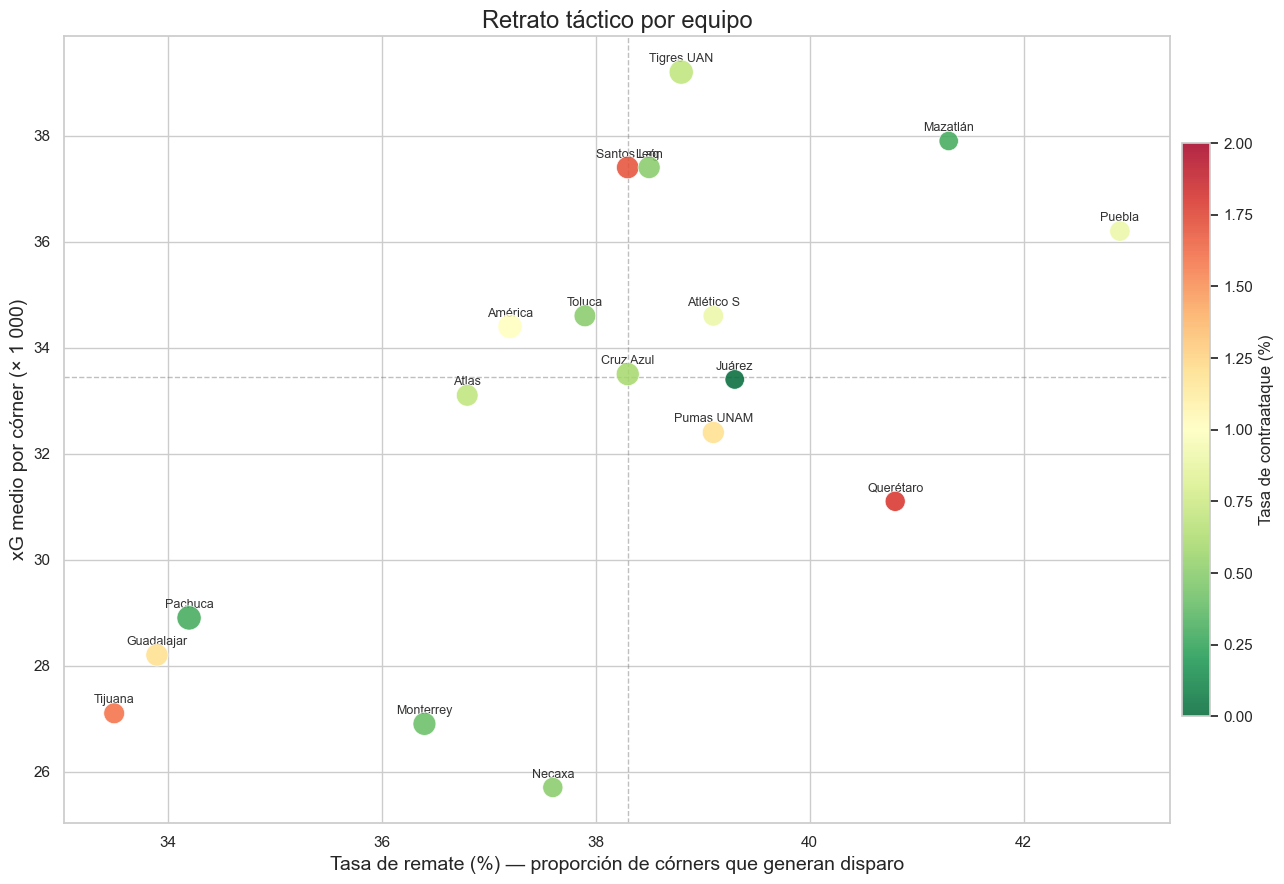

In [ ]:
# ── Scatter de eficiencia: cada punto = un equipo ────────────────────────────
# shot_rate vs xg_mean · tamaño = volumen · color = riesgo de contraataque
fig, ax = plt.subplots(figsize=(13, 9))

sc = ax.scatter(
    team_stats['shot_rate'], team_stats['xg_mean'] * 1000,
    c=team_stats['counter_rate'], cmap='RdYlGn_r',
    s=team_stats['n_corners'] / 3, alpha=0.85, zorder=5,
    vmin=0, vmax=2, edgecolors='white', linewidths=0.5,
)

for _, row in team_stats.iterrows():
    ax.annotate(
        row['team'][:10], (row['shot_rate'], row['xg_mean'] * 1000),
        fontsize=9, ha='center', va='bottom', color='#333',
        xytext=(0, 5), textcoords='offset points',
    )

cbar = fig.colorbar(sc, ax=ax, pad=0.01, fraction=0.025)
cbar.set_label('Tasa de contraataque (%)', fontsize=12)

# Líneas de referencia (mediana)
ax.axvline(team_stats['shot_rate'].median(), color='gray', linestyle='--', alpha=0.5, lw=1)
ax.axhline(team_stats['xg_mean'].median() * 1000, color='gray', linestyle='--', alpha=0.5, lw=1)

ax.set_xlabel('Tasa de remate (%) — proporción de córners que generan disparo', fontsize=14)
ax.set_ylabel('xG medio por córner (× 1 000)', fontsize=14)
ax.set_title('Retrato táctico por equipo', fontsize=17)
plt.tight_layout()
plt.savefig('../figures/team_efficiency_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.11 · Efectividad por franja horaria

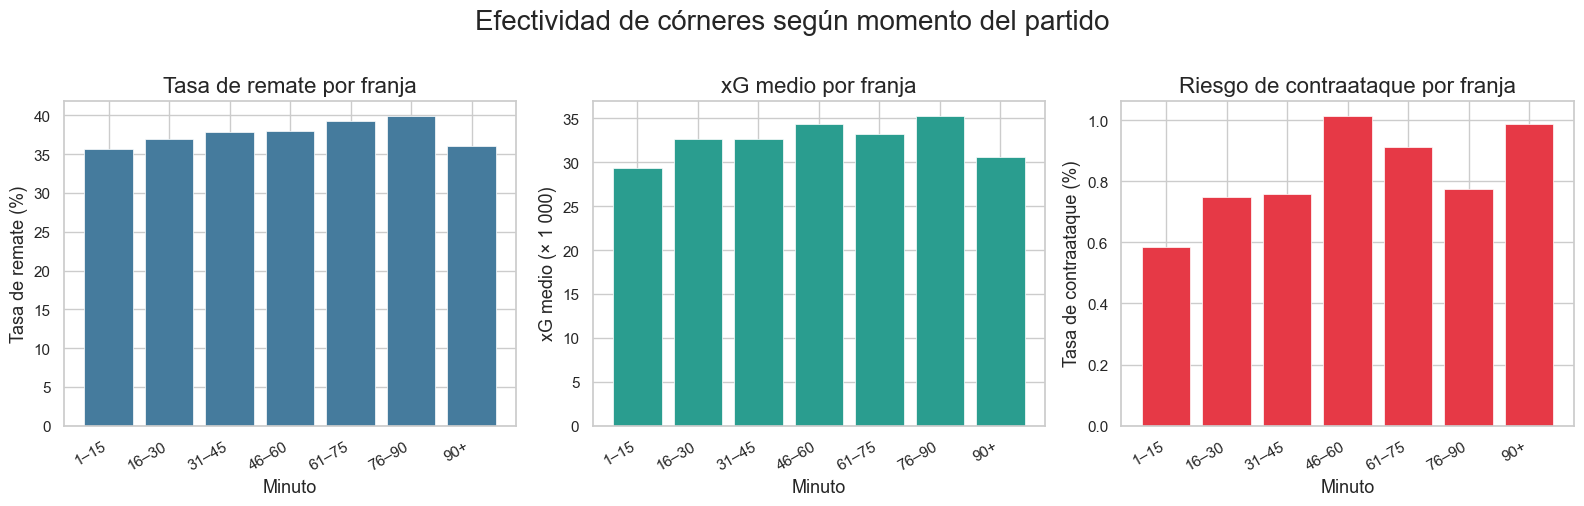

               n  shot_rate  counter_rate  xg_mean
minute_bin                                        
1–15        1881     0.3562        0.0058   0.0293
16–30       1872     0.3697        0.0075   0.0327
31–45       1977     0.3789        0.0076   0.0327
46–60       2565     0.3793        0.0101   0.0344
61–75       1971     0.3927        0.0091   0.0333
76–90       2069     0.3992        0.0077   0.0353
90+          912     0.3607        0.0099   0.0306


In [ ]:
# ── Efectividad de córneres por franja de 15 minutos ─────────────────────────
bins   = [0, 15, 30, 45, 60, 75, 90, 200]
labels = ['1–15', '16–30', '31–45', '46–60', '61–75', '76–90', '90+']

corner_features['minute_bin'] = pd.cut(
    corner_features['minute'], bins=bins, labels=labels, right=True
)

min_eff = (
    corner_features.groupby('minute_bin', observed=False).agg(
        n            = ('id', 'count'),
        shot_rate    = ('generated_shot', 'mean'),
        counter_rate = ('led_to_counter', 'mean'),
        xg_mean      = ('seq_max_xg', lambda x: x.fillna(0).mean()),
    )
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = range(len(labels))

axes[0].bar(x, min_eff['shot_rate'] * 100, color='#457b9d', edgecolor='white', lw=0.5)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=30, ha='right')
axes[0].set_ylabel('Tasa de remate (%)', fontsize=13)
axes[0].set_xlabel('Minuto', fontsize=13)
axes[0].set_title('Tasa de remate por franja', fontsize=16)

axes[1].bar(x, min_eff['xg_mean'] * 1000, color='#2a9d8f', edgecolor='white', lw=0.5)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=30, ha='right')
axes[1].set_ylabel('xG medio (× 1 000)', fontsize=13)
axes[1].set_xlabel('Minuto', fontsize=13)
axes[1].set_title('xG medio por franja', fontsize=16)

axes[2].bar(x, min_eff['counter_rate'] * 100, color='#e63946', edgecolor='white', lw=0.5)
axes[2].set_xticks(x); axes[2].set_xticklabels(labels, rotation=30, ha='right')
axes[2].set_ylabel('Tasa de contraataque (%)', fontsize=13)
axes[2].set_xlabel('Minuto', fontsize=13)
axes[2].set_title('Riesgo de contraataque por franja', fontsize=16)

fig.suptitle('Efectividad de córneres según momento del partido', fontsize=20, y=1.01)
plt.tight_layout()
plt.savefig('../figures/effectiveness_by_minute.png', dpi=150, bbox_inches='tight')
plt.show()

print(min_eff.round(4).to_string())